# Plot data

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import models
from omegaconf import OmegaConf

In [2]:
# !pip install omegaconf

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
import torch

In [4]:
def plot_time_series(path):
    wav = np.load(path)
    plt.figure(figsize=(10,3))
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.ylabel(u"Voltage (\u03bcV)", fontsize=25)
    plt.xticks(np.arange(0,len(wav)+1, 2048), [x/2048 for x in np.arange(0,len(wav)+1, 2048)])
    plt.xlabel("Time (s)", fontsize=25)
    plt.plot(wav)

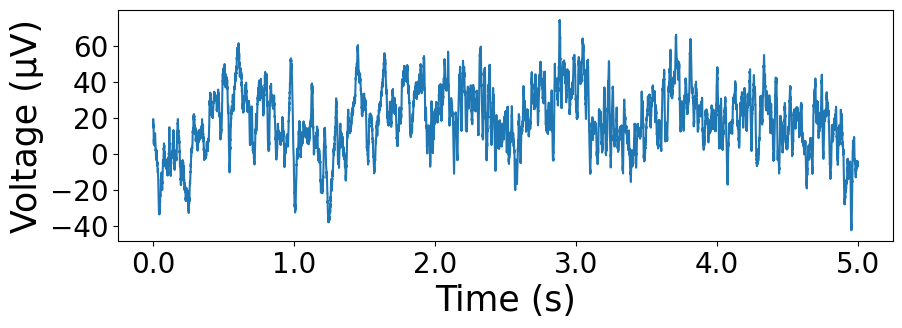

In [5]:
plot_time_series("example_wav_1.npy")

In [6]:
def get_stft(x, fs, clip_fs=-1, normalizing=None, **kwargs):
    f, t, Zxx = signal.stft(x, fs, **kwargs)
   
    Zxx = Zxx[:clip_fs]
    f = f[:clip_fs]

    Zxx = np.abs(Zxx)
    clip = 5 #To handle boundary effects
    if normalizing=="zscore":
        Zxx = Zxx[:,clip:-clip]
        Zxx = stats.zscore(Zxx, axis=-1)
        t = t[clip:-clip]
    elif normalizing=="baselined":
        Zxx = baseline(Zxx[:,clip:-clip])
        t = t[clip:-clip]
    elif normalizing=="db":
        Zxx = np.log2(Zxx[:,clip:-clip])
        t = t[clip:-clip]

    if np.isnan(Zxx).any():
        import pdb; pdb.set_trace()

    return f, t, Zxx

def plot_stft(path):
    wav = np.load(path)
    f,t,linear = get_stft(wav, 2048, clip_fs=40, nperseg=400, noverlap=350, normalizing="zscore", return_onesided=True) #TODO hardcode sampling rate
    plt.figure(figsize=(15,3))
    f[-1]=200
    g1 = plt.pcolormesh(t,f,linear, shading="gouraud", vmin=-3, vmax=5)

    cbar = plt.colorbar(g1)
    tick_font_size = 15
    cbar.ax.tick_params(labelsize=tick_font_size)
    cbar.ax.set_ylabel("Power (Arbitrary units)", fontsize=15)
    plt.xticks(fontsize=20)
    plt.ylabel("")
    plt.yticks(fontsize=20)
    plt.xlabel("Time (s)", fontsize=20)
    plt.ylabel("Frequency (Hz)", fontsize=20)

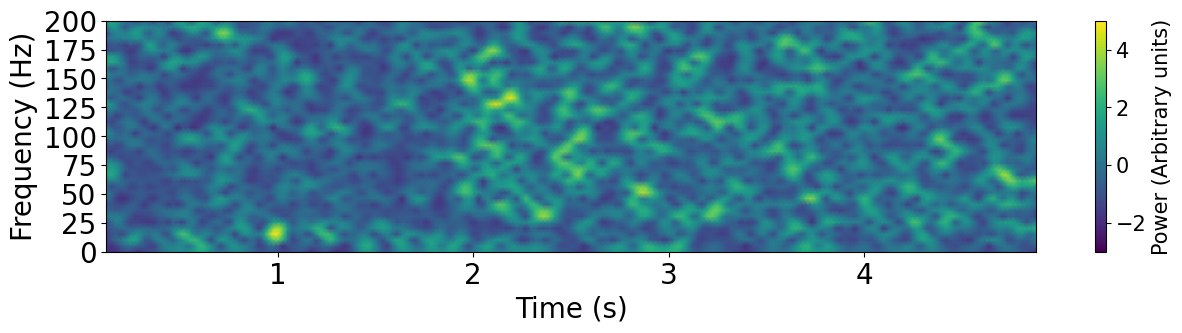

In [7]:
plot_stft("example_wav_1.npy")

# Load model

In [8]:
def build_model(cfg):
    ckpt_path = cfg.upstream_ckpt
    init_state = torch.load(ckpt_path)
    upstream_cfg = init_state["model_cfg"]
    upstream = models.build_model(upstream_cfg)
    return upstream

def load_model_weights(model, states, multi_gpu):
    if multi_gpu:
        model.module.load_weights(states)
    else:
        model.load_weights(states)

---------------------------------------------------------------------------
UnpicklingError                           Traceback (most recent call last)
Cell In[11], line 3
      1 ckpt_path = "../pretrained_weights/stft_large_pretrained.pth"
      2 cfg = OmegaConf.create({"upstream_ckpt": ckpt_path})
----> 3 model = build_model(cfg)
      4 model.to('cuda')
      5 init_state = torch.load(ckpt_path)

Cell In[9], line 3, in build_model(cfg)
      1 def build_model(cfg):
      2     ckpt_path = cfg.upstream_ckpt
----> 3     init_state = torch.load(ckpt_path)
      4     upstream_cfg = init_state["model_cfg"]
      5     upstream = models.build_model(upstream_cfg)

File /usr/local/lib/python3.12/dist-packages/torch/serialization.py:1524, in load(f, map_location, pickle_module, weights_only, mmap, **pickle_load_args)
   1516                 return _load(
   1517                     opened_zipfile,
   1518                     map_location,
   (...)   1521                     **pickle_load_args,
   1522                 )
   1523             except pickle.UnpicklingError as e:
-> 1524                 raise pickle.UnpicklingError(_get_wo_message(str(e))) from None
   1525         return _load(
   1526             opened_zipfile,
   1527             map_location,
   (...)   1530             **pickle_load_args,
   1531         )
   1532 if mmap:

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL omegaconf.dictconfig.DictConfig was not an allowed global by default. Please use `torch.serialization.add_safe_globals([omegaconf.dictconfig.DictConfig])` or the `torch.serialization.safe_globals([omegaconf.dictconfig.DictConfig])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weights_only https://pytorch.org/docs/stable/generated/torch.load.html.

In [9]:
torch.serialization.add_safe_globals?

Signature:
torch.serialization.add_safe_globals(
    safe_globals: list[typing.Union[typing.Callable, tuple[typing.Callable, str]]],
) -> None
Docstring:
Marks the given globals as safe for ``weights_only`` load. For example, functions
added to this list can be called during unpickling, classes could be instantiated
and have state set.

Each item in the list can either be a function/class or a tuple of the form
(function/class, string) where string is the full path of the function/class.

Within the serialized format, each function is identified with its full
path as ``{__module__}.{__qualname__}``. When calling this API, you can provide this
full path that should match the one in the checkpoint otherwise the default
``{fn.__module__}.{fn.__qualname__}`` will be used.

Args:
    safe_globals (List[Union[Callable, Tuple[Callable, str]]]): list of globals to mark as safe

Example:
    >>> # xdoctest: +SKIP("Can't torch.save(t, ...) as doctest thinks MyTensor is defined on torch.serializa

In [10]:
import omegaconf
import typing
import collections
# torch.serialization.add_safe_globals([omegaconf]) # caused more errors
torch.serialization.add_safe_globals([
    omegaconf.dictconfig.DictConfig,
    omegaconf.base.ContainerMetadata,
    typing.Any,
    dict,
    collections.defaultdict,
    omegaconf.nodes.AnyNode,
    omegaconf.base.Metadata])

In [11]:
ckpt_path = "../pretrained_weights/stft_large_pretrained.pth"
cfg = OmegaConf.create({"upstream_ckpt": ckpt_path})
model = build_model(cfg)
model.to('cuda')
init_state = torch.load(ckpt_path)
load_model_weights(model, init_state['model'], False)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


# Get output

In [12]:
path = "example_wav_1.npy"
wav = np.load(path)

f,t,linear = get_stft(wav, 2048, clip_fs=40, nperseg=400, noverlap=350, normalizing="zscore", return_onesided=True) #TODO hardcode sampling rate
inputs = torch.FloatTensor(linear).unsqueeze(0).transpose(1,2).to('cuda')
mask = torch.zeros((inputs.shape[:2])).bool().to('cuda')
with torch.no_grad():
    out = model.forward(inputs, mask, intermediate_rep=True)

In [13]:
inputs.shape, out.shape

(torch.Size([1, 196, 40]), torch.Size([1, 196, 768]))